# PZ data challenge: task set 3

**Task set 3: non-representative training, plus COSMOS2020 many-band photo-z.** The reference redshift is:
- the spectroscopic redshift (`redshift`) for objects selected by a spectroscopic survey;
- `redshift_manyband` for objects selected only by COSMOS2020, whose `redshift` is NaN.

The COSMOS-only objects are the faint, test-like part of the training set, but they can only be scored against their many-band photo-z, so their metrics include the label noise.

This notebook runs all four configurations of the task set (cardinal and flagship, 1yr and 10yr). For each one it:

1. trains the CNN ensemble on the training file, holding out `VAL_FRAC` of it for evaluation (test redshifts are hidden);
2. scores the held-out objects with the challenge's metrics. The point metrics (bias, scatter, |Δz| > 0.2 rate) match RAIL's biweight statistics, and the PIT metrics come from `qp.metrics.pit.PIT`, as in the challenge evaluator;
3. writes the submission files under their official names into `OUT_DIR`, shared by all four task-set notebooks:
   - the test-set p(z) (subtask 1), checked with the challenge's own format check;
   - the trained ensemble as a single `.pkl` (subtask 2), via `znn.save_ensemble_file`.

Every p(z), on held-out and test objects, comes from `znn.ensemble_predict_resampled`. It redraws the photometry `N_SAMPLES` times from the catalogue's `_err` columns, runs every ensemble member on every draw, and takes a Gaussian with the mean and spread of those predictions. The width therefore includes both the spread between members and the photometric errors. `N_SAMPLES = 50` was enough for the results to converge on Cardinal Y1 (`CNN_photoz-ensemble-cardinal_noise_realizations.ipynb`).

Run this from the repo root with the `qp` conda env as the kernel. The filter curves are the ones shipped with RAIL, which `pz_data_challenge` installs.

## Configuration

In [1]:
from rail.utils.path_utils import find_rail_file

import znn  # run from the repo root so this picks up the local source

TASKSET = 3
SIMS = ["cardinal", "flagship"]
SCENARIOS = ["1yr", "10yr"]

DATA_DIR = "../pz_data_challenge/scripts/public"
# Training starting point: "popcosmos" (the pre-training shipped with znn) or None (from scratch). Each choice
# writes to its own directory, so runs with and without pre-training never overwrite each other.
PRETRAINING = "popcosmos"
OUT_DIR = "outputs/znn" if PRETRAINING is None else f"outputs/znn_pretrained_{PRETRAINING}"  # submission files for all task sets; the contents of the submission tarball

# Filter curves shipped with RAIL; the challenge's catalogs.yaml ("cardinal_roman_rubin") maps the
# catalogue columns to these DC2LSST_* and roman_* filters
FILTER_DIR = find_rail_file("examples_data/estimation_data/data/FILTER")

# band -> (catalogue magnitude column, filter curve file), ordered by wavelength
BANDS = {
    "u": ("mag_u_lsst", f"{FILTER_DIR}/DC2LSST_u.res"),
    "g": ("mag_g_lsst", f"{FILTER_DIR}/DC2LSST_g.res"),
    "r": ("mag_r_lsst", f"{FILTER_DIR}/DC2LSST_r.res"),
    "i": ("mag_i_lsst", f"{FILTER_DIR}/DC2LSST_i.res"),
    "z": ("mag_z_lsst", f"{FILTER_DIR}/DC2LSST_z.res"),
    "y": ("mag_y_lsst", f"{FILTER_DIR}/DC2LSST_y.res"),
    "Y": ("mag_Y_roman", f"{FILTER_DIR}/roman_Y106.res"),
    "J": ("mag_J_roman", f"{FILTER_DIR}/roman_J129.res"),
    "H": ("mag_H_roman", f"{FILTER_DIR}/roman_H158.res"),
}
REF_BAND = "i"  # magnitudes are normalized by this band
FEATURE_CONFIG = znn.DEFAULT_FEATURE_CONFIG

# Photometric error propagation at prediction time: magnitude column -> its error column
ERRORS = {col: f"{col}_err" for col, _ in BANDS.values()}
N_SAMPLES = 50  # noise draws per object; converged by 50 on Cardinal Y1
NOISE_SEED = 42

VAL_FRAC = 0.2  # fraction of the training set held out for evaluation
N_SPLITS = 5  # ensemble members (K-fold); 10 in the full setup
EPOCHS = 100  # max epochs per member (early stopping usually ends sooner)
SEED = 42

I0000 00:00:1791449851.406070  345032 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qp.metrics.pit import PIT
from sklearn.model_selection import train_test_split

from pz_data_challenge import scoring, submit_utils

os.makedirs(OUT_DIR, exist_ok=True)
print("znn from", znn.__file__)

znn from /global/u2/j/jaimerz/UCL/mlpz_cnn_deepset/znn/__init__.py


## Reference redshifts and evaluation subsets

In [3]:
SPEC_SURVEYS = ["DEEP2_LSST", "DESI_BGS", "DESI_ELG_LOP", "DESI_LRG", "VVDSf02", "zCOSMOS"]


def reference_redshifts(train):
    """Reference redshift per training object, and the held-out subsets to score."""
    is_spec = train[[c for c in SPEC_SURVEYS if c in train]].astype(bool).any(axis=1).to_numpy()
    is_cosmos = train["COSMOS"].astype(bool).to_numpy()
    is_cosmos_only = is_cosmos & ~is_spec
    z_spec = train["redshift"].to_numpy()
    z_manyband = train["redshift_manyband"].to_numpy()
    assert np.isnan(z_spec[is_cosmos_only]).all() and np.isfinite(z_spec[is_spec]).all()

    z_ref = np.where(is_cosmos_only, z_manyband, z_spec)
    assert np.isfinite(z_ref).all(), "every training object should have a reference redshift"

    # How noisy are the many-band labels? Measured on objects with both a spec-z and a many-band photo-z,
    # which are bright, so this understates the noise at the faint end.
    overlap = is_cosmos & is_spec
    dz = (z_manyband[overlap] - z_spec[overlap]) / (1 + z_spec[overlap])
    bias, _, scatter, _, outliers = znn.get_biweight_mean_sigma_outlier(dz)
    print(
        f"spec-selected: {is_spec.mean():.1%}, COSMOS-only: {is_cosmos_only.mean():.1%}; many-band vs spec-z on "
        f"{overlap.sum()} overlap objects: bias {bias:.4f}, scatter {scatter:.4f}, |dz|>0.2 rate {outliers:.4f}"
    )

    subsets = {
        "held-out spec-selected (vs spec-z)": is_spec,
        "held-out COSMOS-only (vs many-band photo-z)": is_cosmos_only,
        "held-out all": np.ones(len(train), dtype=bool),
    }
    return z_ref, subsets

## Evaluation helpers

In [4]:
redshift_bins = np.linspace(0, 2.5, 11)
imag_bins = np.linspace(18, 25.5, 11)


def predict(trained_models, df, rng):
    """p(z) of the ensemble with the photometric errors propagated (N_SAMPLES draws per object)."""
    return znn.ensemble_predict_resampled(
        trained_models, df, ERRORS, N_SAMPLES, rng, BANDS, REF_BAND, FEATURE_CONFIG, ids=df["object_id"].to_numpy()
    )


def evaluate(trained_models, df_eval, z_eval, rng, title):
    """Point and PIT metrics of the ensemble on one set of objects."""
    pz = predict(trained_models, df_eval, rng)
    mag_i = df_eval["mag_i_lsst"].to_numpy()
    z_point = np.squeeze(pz.ancil["zmode"])

    point_stats, redshift_stats, imag_stats = znn.get_all_stats(
        z_eval, z_point, mag_i, save=False, redshift_bins=redshift_bins, imag_bins=imag_bins
    )
    znn.plot_stats(point_stats, redshift_stats, imag_stats, z_eval, z_point, redshift_bins, imag_bins, mag_i)
    plt.suptitle(f"{title} ({len(z_eval)} objects)", y=1.02)
    plt.show()

    mean, _, std, _, abs_outlier_rate = point_stats
    pit = PIT(pz, z_eval)
    values = {
        "mean": mean,
        "std": std,
        "abs_outlier_rate": abs_outlier_rate,
        "ks": pit.evaluate_PIT_KS().statistic,
        "CvM": pit.evaluate_PIT_CvM().statistic,
        "ksamp": pit.evaluate_PIT_anderson_ksamp().statistic,
        # qp derives this from a spline fit to the PIT quantiles; it breaks down (huge values) when PIT
        # piles up at 0 or 1. The challenge evaluator uses the same call.
        "outlier": pit.evaluate_PIT_outlier_rate(),
        "pit_outlier_direct": np.mean((pit.pit_samps < 0.0001) | (pit.pit_samps > 0.9999)),
    }
    return values


def tier_points(values):
    """Points against the challenge scoring tiers: one per nested range a metric falls inside."""
    return {name: sum(lo <= float(values[name]) <= hi for lo, hi in ranges) for name, ranges in scoring.metric_dict.items()}

## Run all configurations

For each configuration: train on the fit split, score the held-out subsets, then write the test-set p(z) and the model file. The model used for the submission files is the one trained on the fit split.


========== task set 3: cardinal_1yr ==========
spec-selected: 64.9%, COSMOS-only: 35.1%; many-band vs spec-z on 4284 overlap objects: bias 0.0003, scatter 0.0135, |dz|>0.2 rate 0.0047


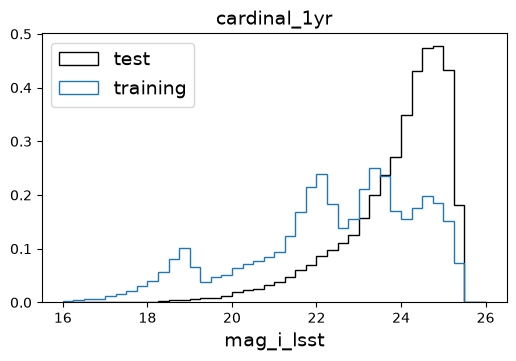

I0000 00:00:1791449881.508795  345032 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79189 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:03:00.0, compute capability: 8.0
I0000 00:00:1791449881.512658  345032 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 79189 MB memory:  -> device: 1, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:41:00.0, compute capability: 8.0
I0000 00:00:1791449881.516497  345032 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 79189 MB memory:  -> device: 2, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:82:00.0, compute capability: 8.0
I0000 00:00:1791449881.520185  345032 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 79189 MB memory:  -> device: 3, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:c1:00.0, compute capability: 8.0



--- Fold 1/5 ---
Epoch 1/100


I0000 00:00:1791449885.066704  345490 service.cc:153] XLA service 0x7f7e70035160 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1791449885.066732  345490 service.cc:161]   StreamExecutor [0]: NVIDIA A100-SXM4-80GB, Compute Capability 8.0 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.27.0)
I0000 00:00:1791449885.066742  345490 service.cc:161]   StreamExecutor [1]: NVIDIA A100-SXM4-80GB, Compute Capability 8.0 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.27.0)
I0000 00:00:1791449885.066745  345490 service.cc:161]   StreamExecutor [2]: NVIDIA A100-SXM4-80GB, Compute Capability 8.0 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.27.0)
I0000 00:00:1791449885.066748  345490 service.cc:161]   StreamExecutor [3]: NVIDIA A100-SXM4-80GB, Compute Capability 8.0 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.27.0)
I0000 00:00:1791449885.099554  345490 dump_mlir_util.cc:269] disabling MLIR crash repro

250/250 - 15s - 60ms/step - loss: 0.0073 - val_loss: 0.0051 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0058 - val_loss: 0.0045 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 0.0054 - val_loss: 0.0045 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 0.0053 - val_loss: 0.0045 - learning_rate: 0.0010
Epoch 5/100

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 0.0052 - val_loss: 0.0045 - learning_rate: 0.0010
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 0.0049 - val_loss: 0.0044 - learning_rate: 5.0000e-04
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 0.0048 - val_loss: 0.0042 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 0.0047 - val_loss: 0.0043 - learning_rate: 5.0000e-04
Epoch 9/100
250/250 - 1s - 3ms/step - loss: 0.0047 - val_loss: 0.0043 - learning_rate: 5.0000e-04
Epoch 10/100

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0

I0000 00:00:1791449910.982100  345493 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_23520__.37


...

250/250 - 5s - 19ms/step - loss: 0.0066 - val_loss: 0.0058 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0054 - val_loss: 0.0058 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 0.0052 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 0.0051 - val_loss: 0.0055 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 0.0050 - val_loss: 0.0055 - learning_rate: 0.0010
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 0.0049 - val_loss: 0.0055 - learning_rate: 0.0010
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 0.0048 - val_loss: 0.0054 - learning_rate: 0.0010
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 0.0047 - val_loss: 0.0054 - learning_rate: 0.0010
Epoch 9/100

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 0.0046 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 10/100
250/250 - 1s - 3ms/step - loss: 0.0044 - val_loss: 0.0053 - learning_rate: 

I0000 00:00:1791449942.696172  345489 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_63008__.37


250/250 - 5s - 18ms/step - loss: 0.0070 - val_loss: 0.0048 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0058 - val_loss: 0.0046 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 0.0055 - val_loss: 0.0045 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 0.0053 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 0.0052 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 0.0051 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 0.0050 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 0.0047 - val_loss: 0.0043 - learning_rate: 5.0000e-04
Epoch 9/100
250/250 - 1s - 3ms/step - loss: 0.0047 - val_loss: 0.0043 - learning_rate: 5.0000e-04
Epoch 10/100
250/250 - 1s - 3ms/step - loss: 0.0046 - val_loss: 0.0042 - learnin

I0000 00:00:1791449957.793871  345489 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_81775__.37


250/250 - 5s - 19ms/step - loss: 0.0070 - val_loss: 0.0051 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0056 - val_loss: 0.0048 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 0.0053 - val_loss: 0.0050 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 0.0051 - val_loss: 0.0048 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 0.0050 - val_loss: 0.0046 - learning_rate: 0.0010
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 0.0049 - val_loss: 0.0047 - learning_rate: 0.0010
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 0.0048 - val_loss: 0.0047 - learning_rate: 0.0010
Epoch 8/100

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 0.0048 - val_loss: 0.0046 - learning_rate: 0.0010
Epoch 9/100
250/250 - 1s - 3ms/step - loss: 0.0045 - val_loss: 0.0045 - learning_rate: 5.0000e-04
Epoch 10/100
250/250 - 1s - 3ms/step - loss: 0.0044 - val_loss: 0.0046 - learning_ra

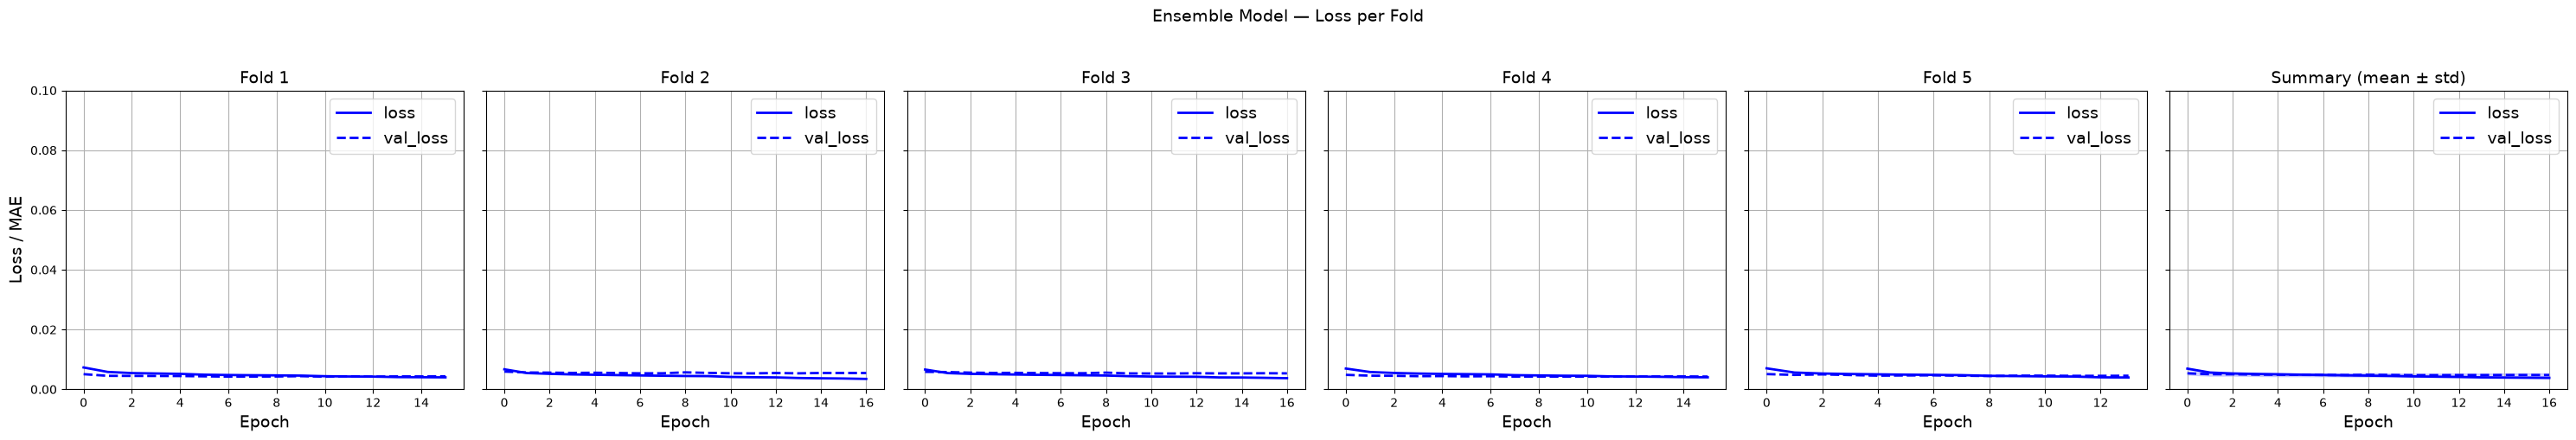

/global/u2/j/jaimerz/UCL/mlpz_cnn_deepset/znn/plotting.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


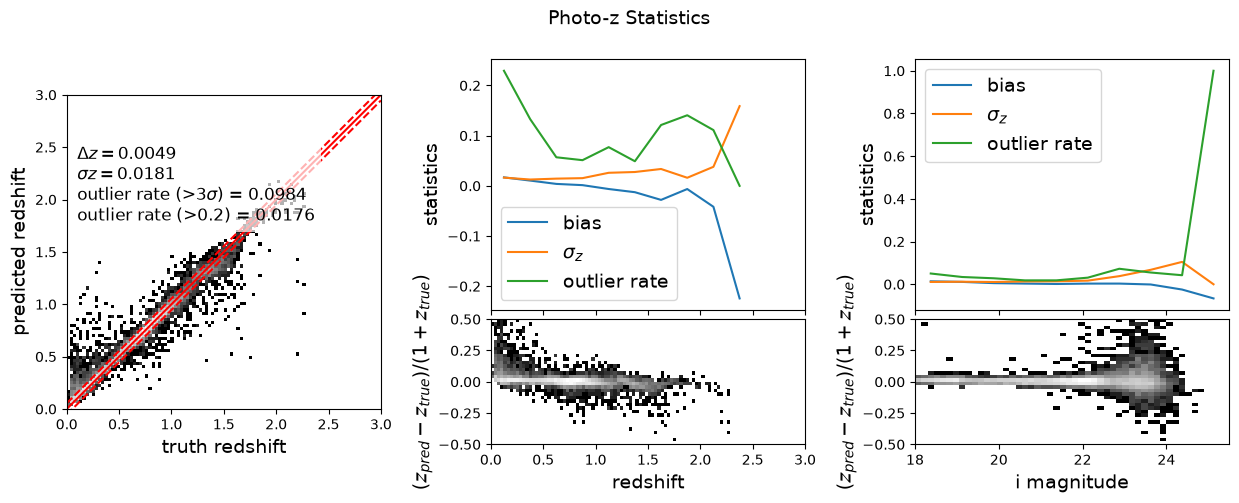

<Figure size 640x480 with 0 Axes>

/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/qp/metrics/array_metrics.py:27: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  return stats.anderson_ksamp([p_random_variables, q_random_variables], **kwargs)
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/qp/metrics/array_metrics.py:27: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  return stats.anderson_ksamp([p_random_variables, q_random_variables], **kwargs)
/global/u2/j/jaimerz/UCL/mlpz_cnn_deepset/znn/data.py:157: RuntimeWarning: invalid value encountered in subtract
  mags_normed = mags - mag_i[None, :]  # normalize by i-band mag, per band, before binning
/global/homes/j/jaimerz/envs/pzdc/lib/

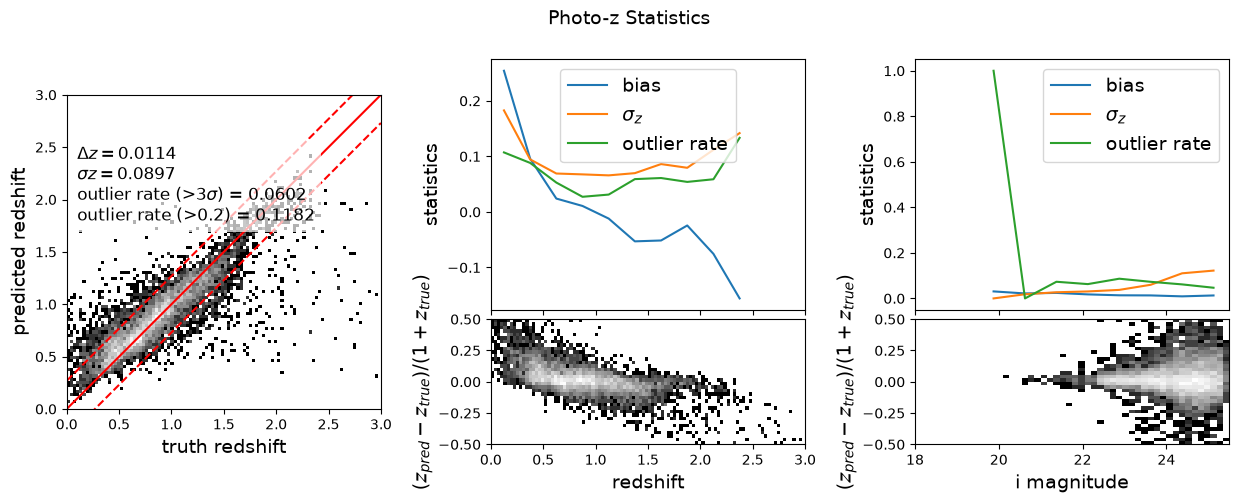

<Figure size 640x480 with 0 Axes>

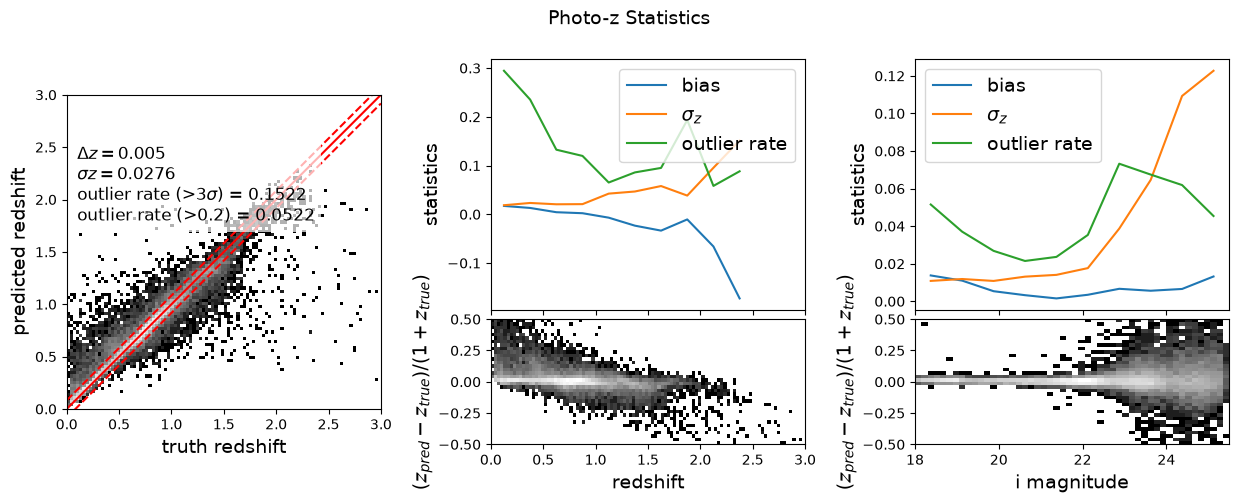

<Figure size 640x480 with 0 Axes>

outputs/znn_pretrained_popcosmos/pz_challenge_taskset_3_cardinal_pz_estimate_1yr.hdf5 checks passed: [1, 2, 3, 4, 5, 6, 7]

========== task set 3: cardinal_10yr ==========
spec-selected: 63.4%, COSMOS-only: 36.6%; many-band vs spec-z on 4359 overlap objects: bias -0.0001, scatter 0.0132, |dz|>0.2 rate 0.0083


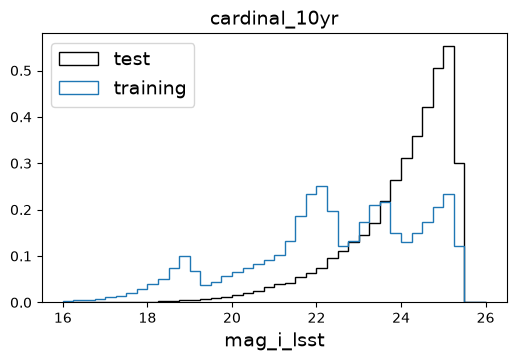


--- Fold 1/5 ---
Epoch 1/100


I0000 00:00:1791450163.038294  345493 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_193328__.37


250/250 - 5s - 18ms/step - loss: 0.0058 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0050 - val_loss: 0.0033 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 0.0049 - val_loss: 0.0033 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 0.0048 - val_loss: 0.0033 - learning_rate: 0.0010
Epoch 5/100

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 0.0047 - val_loss: 0.0032 - learning_rate: 0.0010
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 0.0045 - val_loss: 0.0030 - learning_rate: 5.0000e-04
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 0.0045 - val_loss: 0.0030 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 0.0045 - val_loss: 0.0032 - learning_rate: 5.0000e-04
Epoch 9/100

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 0.0044 - val_loss: 0.0031 - learning_rate: 5.0000

I0000 00:00:1791450180.317337  345490 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_214984__.37


250/250 - 5s - 18ms/step - loss: 0.0055 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0048 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 0.0046 - val_loss: 0.0041 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 0.0045 - val_loss: 0.0045 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 0.0045 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 6/100

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 0.0044 - val_loss: 0.0041 - learning_rate: 0.0010
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 0.0042 - val_loss: 0.0040 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 0.0042 - val_loss: 0.0040 - learning_rate: 5.0000e-04
Epoch 9/100
250/250 - 1s - 3ms/step - loss: 0.0042 - val_loss: 0.0040 - learning_rate: 5.0000e-04
Epoch 10/100
250/250 - 1s - 3ms/step - loss: 0.0041 - val_loss: 0.0040 - lea

...

250/250 - 5s - 18ms/step - loss: 0.0053 - val_loss: 0.0047 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0047 - val_loss: 0.0045 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 0.0045 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 0.0045 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 5/100

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 0.0044 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 0.0043 - val_loss: 0.0043 - learning_rate: 5.0000e-04
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 0.0042 - val_loss: 0.0043 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 0.0042 - val_loss: 0.0043 - learning_rate: 5.0000e-04
Epoch 9/100

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 0.0042 - val_loss: 0.0043 - learning_rate: 5.0000

I0000 00:00:1791450206.160805  345491 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_245660__.37


250/250 - 5s - 18ms/step - loss: 0.0054 - val_loss: 0.0049 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0047 - val_loss: 0.0048 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 0.0044 - val_loss: 0.0049 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 0.0044 - val_loss: 0.0047 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 0.0043 - val_loss: 0.0050 - learning_rate: 0.0010
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 0.0043 - val_loss: 0.0047 - learning_rate: 0.0010
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 0.0042 - val_loss: 0.0048 - learning_rate: 0.0010
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 0.0041 - val_loss: 0.0046 - learning_rate: 5.0000e-04
Epoch 9/100
250/250 - 1s - 3ms/step - loss: 0.0040 - val_loss: 0.0046 - learning_rate: 5.0000e-04
Epoch 10/100

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000

I0000 00:00:1791450221.326221  345492 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_264395__.37


250/250 - 5s - 19ms/step - loss: 0.0054 - val_loss: 0.0047 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0047 - val_loss: 0.0046 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 0.0045 - val_loss: 0.0045 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 0.0044 - val_loss: 0.0045 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 0.0043 - val_loss: 0.0045 - learning_rate: 0.0010
Epoch 6/100

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 0.0043 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 0.0041 - val_loss: 0.0044 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 0.0041 - val_loss: 0.0044 - learning_rate: 5.0000e-04
Epoch 9/100
250/250 - 1s - 3ms/step - loss: 0.0040 - val_loss: 0.0044 - learning_rate: 5.0000e-04
Epoch 10/100
250/250 - 1s - 3ms/step - loss: 0.0040 - val_loss: 0.0044 - lea

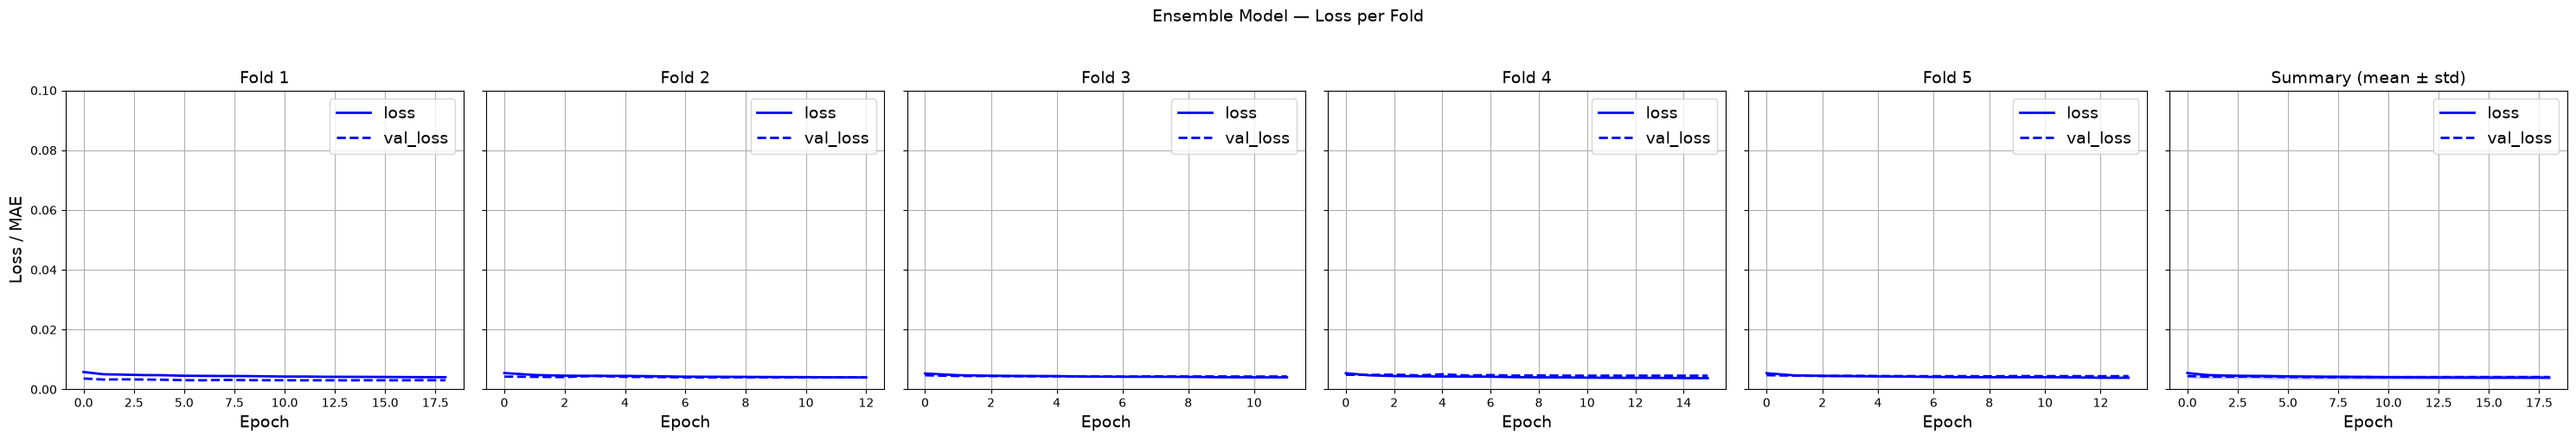

/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/u2/j/jaimerz/UCL/mlpz_cnn_deepset

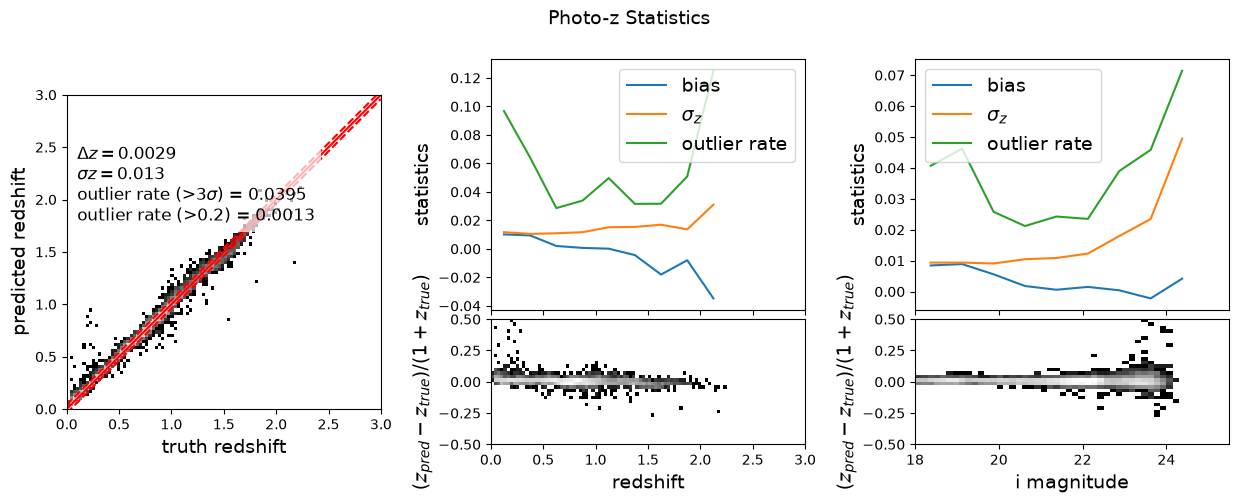

<Figure size 640x480 with 0 Axes>

/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/qp/metrics/array_metrics.py:27: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  return stats.anderson_ksamp([p_random_variables, q_random_variables], **kwargs)
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/qp/metrics/array_metrics.py:27: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  return stats.anderson_ksamp([p_random_variables, q_random_variables], **kwargs)


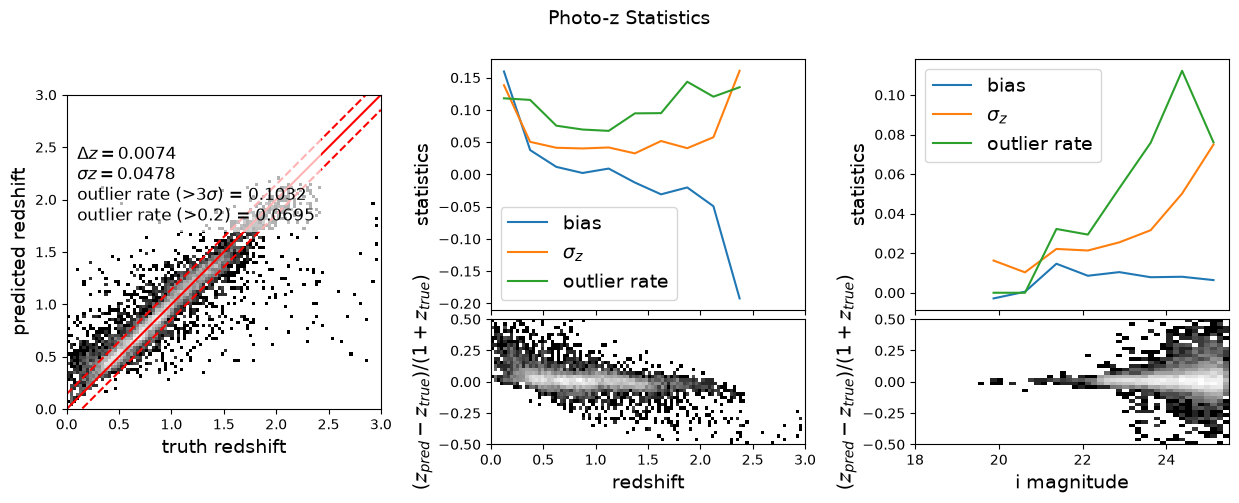

<Figure size 640x480 with 0 Axes>

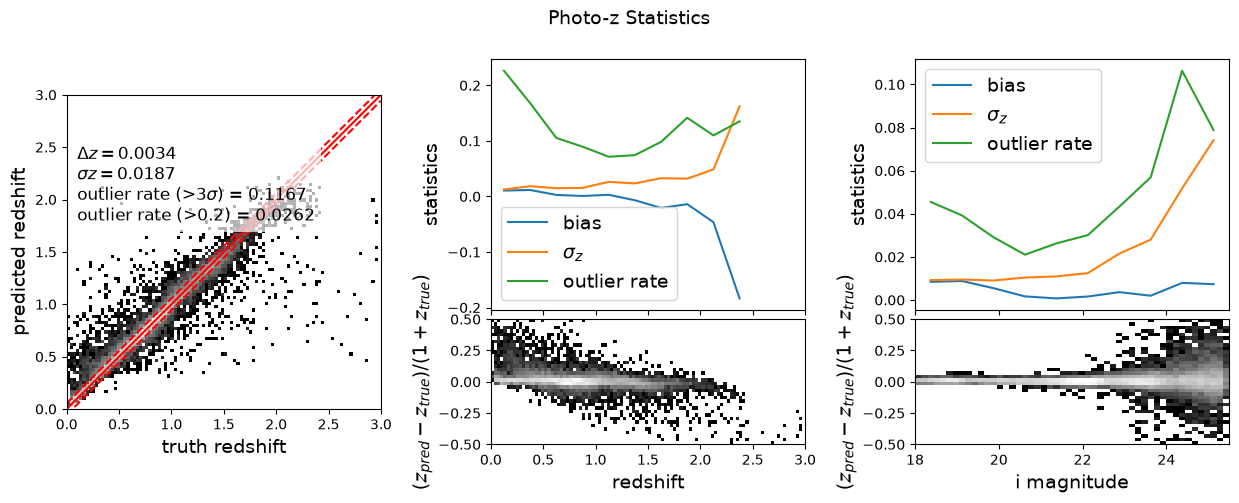

<Figure size 640x480 with 0 Axes>

outputs/znn_pretrained_popcosmos/pz_challenge_taskset_3_cardinal_pz_estimate_10yr.hdf5 checks passed: [1, 2, 3, 4, 5, 6, 7]

========== task set 3: flagship_1yr ==========
spec-selected: 47.5%, COSMOS-only: 52.5%; many-band vs spec-z on 5479 overlap objects: bias 0.0001, scatter 0.0128, |dz|>0.2 rate 0.0073


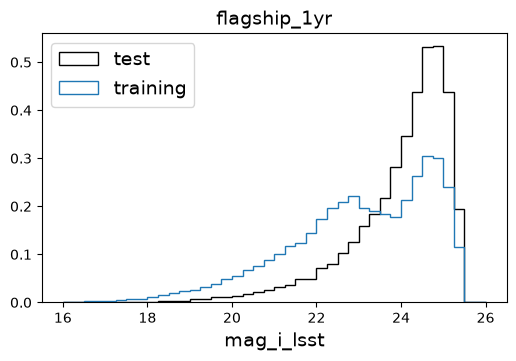


--- Fold 1/5 ---
Epoch 1/100


I0000 00:00:1791450424.845243  345491 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_375948__.37


250/250 - 5s - 20ms/step - loss: 0.0103 - val_loss: 0.0082 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0085 - val_loss: 0.0080 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 0.0081 - val_loss: 0.0082 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 0.0079 - val_loss: 0.0080 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 0.0078 - val_loss: 0.0075 - learning_rate: 0.0010
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 0.0077 - val_loss: 0.0075 - learning_rate: 0.0010
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 0.0076 - val_loss: 0.0076 - learning_rate: 0.0010
Epoch 8/100

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 0.0074 - val_loss: 0.0078 - learning_rate: 0.0010
Epoch 9/100
250/250 - 1s - 3ms/step - loss: 0.0072 - val_loss: 0.0075 - learning_rate: 5.0000e-04
Epoch 10/100
250/250 - 1s - 3ms/step - loss: 0.0070 - val_loss: 0.0073 - learning_ra

I0000 00:00:1791450440.050570  345491 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_393687__.37


250/250 - 5s - 20ms/step - loss: 0.0102 - val_loss: 0.0084 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0084 - val_loss: 0.0082 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 0.0080 - val_loss: 0.0080 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 0.0078 - val_loss: 0.0082 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 0.0076 - val_loss: 0.0081 - learning_rate: 0.0010
Epoch 6/100

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 0.0074 - val_loss: 0.0080 - learning_rate: 0.0010
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 0.0071 - val_loss: 0.0078 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 0.0070 - val_loss: 0.0077 - learning_rate: 5.0000e-04
Epoch 9/100
250/250 - 1s - 3ms/step - loss: 0.0069 - val_loss: 0.0078 - learning_rate: 5.0000e-04
Epoch 10/100

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.000250

...

250/250 - 5s - 20ms/step - loss: 0.0102 - val_loss: 0.0077 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0085 - val_loss: 0.0074 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 0.0083 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 0.0081 - val_loss: 0.0070 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 0.0078 - val_loss: 0.0074 - learning_rate: 0.0010
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 0.0078 - val_loss: 0.0070 - learning_rate: 0.0010
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 0.0077 - val_loss: 0.0070 - learning_rate: 0.0010
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 0.0077 - val_loss: 0.0070 - learning_rate: 0.0010
Epoch 9/100

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 0.0075 - val_loss: 0.0070 - learning_rate: 0.0010
Epoch 10/100
250/250 - 1s - 3ms/step - loss: 0.0072 - val_loss: 0.0069 - learning_rate: 

I0000 00:00:1791450468.953291  345489 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_427281__.37


250/250 - 5s - 19ms/step - loss: 0.0102 - val_loss: 0.0081 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0085 - val_loss: 0.0079 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 0.0081 - val_loss: 0.0076 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 0.0079 - val_loss: 0.0079 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 0.0077 - val_loss: 0.0075 - learning_rate: 0.0010
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 0.0076 - val_loss: 0.0077 - learning_rate: 0.0010
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 0.0075 - val_loss: 0.0076 - learning_rate: 0.0010
Epoch 8/100

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 0.0075 - val_loss: 0.0077 - learning_rate: 0.0010
Epoch 9/100
250/250 - 1s - 3ms/step - loss: 0.0071 - val_loss: 0.0075 - learning_rate: 5.0000e-04
Epoch 10/100
250/250 - 1s - 3ms/step - loss: 0.0070 - val_loss: 0.0074 - learning_ra

I0000 00:00:1791450484.644625  345489 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_445984__.37


250/250 - 5s - 20ms/step - loss: 0.0102 - val_loss: 0.0082 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0084 - val_loss: 0.0079 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 0.0081 - val_loss: 0.0078 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 0.0079 - val_loss: 0.0074 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 0.0077 - val_loss: 0.0076 - learning_rate: 0.0010
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 0.0075 - val_loss: 0.0075 - learning_rate: 0.0010
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 0.0075 - val_loss: 0.0074 - learning_rate: 0.0010
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 0.0071 - val_loss: 0.0074 - learning_rate: 5.0000e-04
Epoch 9/100
250/250 - 1s - 3ms/step - loss: 0.0069 - val_loss: 0.0074 - learning_rate: 5.0000e-04
Epoch 10/100

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000

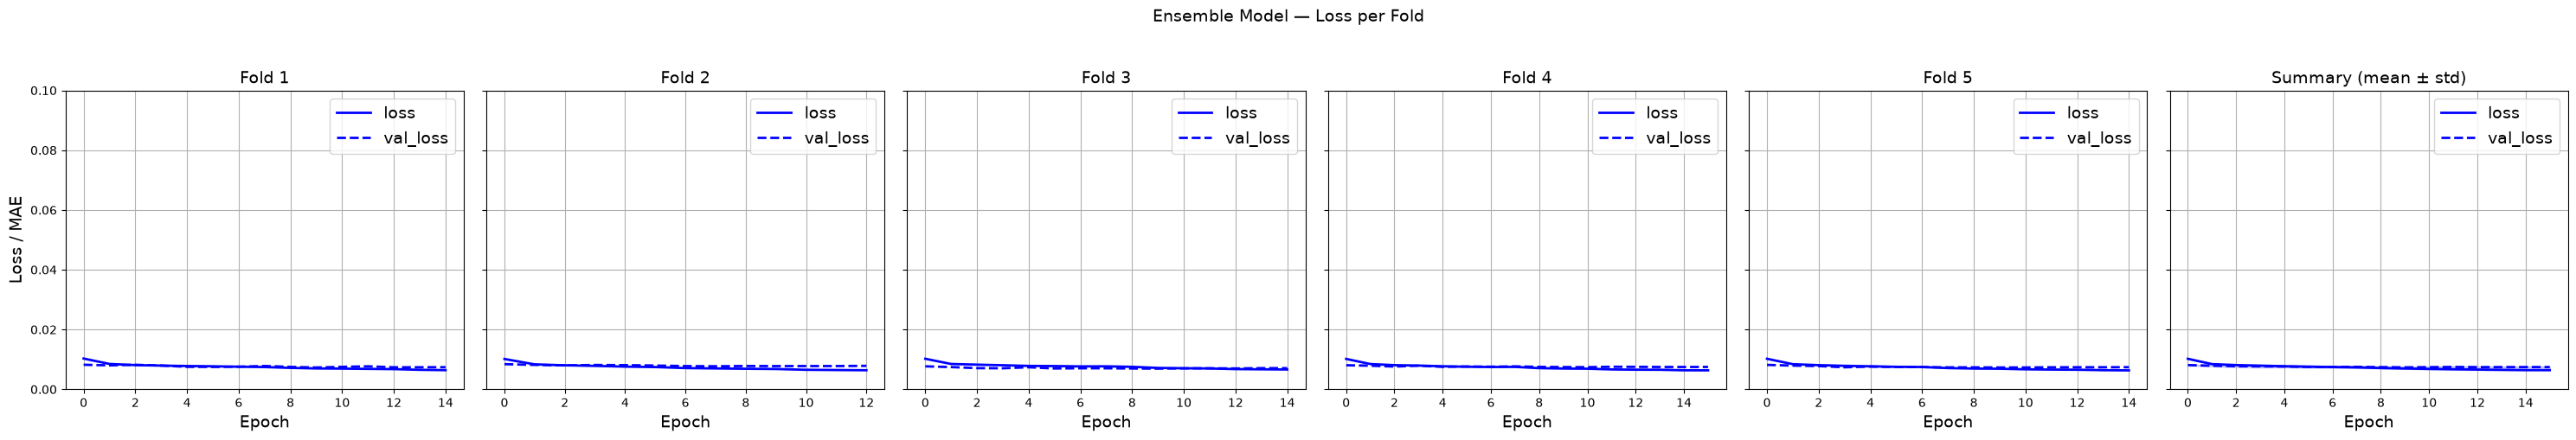

/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/u2/j/jaimerz/UCL/mlpz_cnn_deepset

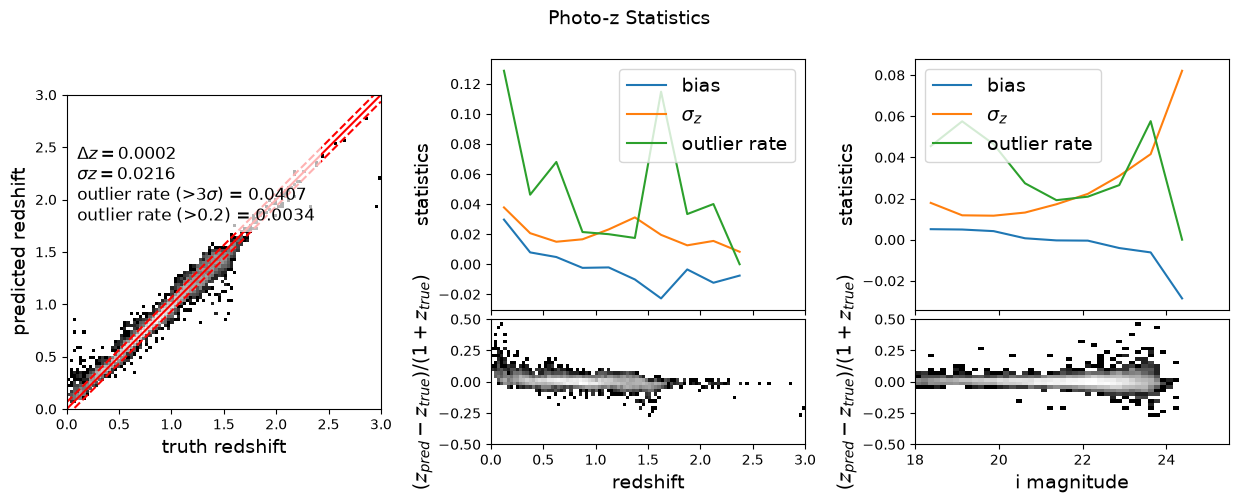

<Figure size 640x480 with 0 Axes>

/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/qp/metrics/array_metrics.py:27: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  return stats.anderson_ksamp([p_random_variables, q_random_variables], **kwargs)
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/qp/metrics/array_metrics.py:27: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  return stats.anderson_ksamp([p_random_variables, q_random_variables], **kwargs)
/global/u2/j/jaimerz/UCL/mlpz_cnn_deepset/znn/data.py:157: RuntimeWarning: invalid value encountered in subtract
  mags_normed = mags - mag_i[None, :]  # normalize by i-band mag, per band, before binning


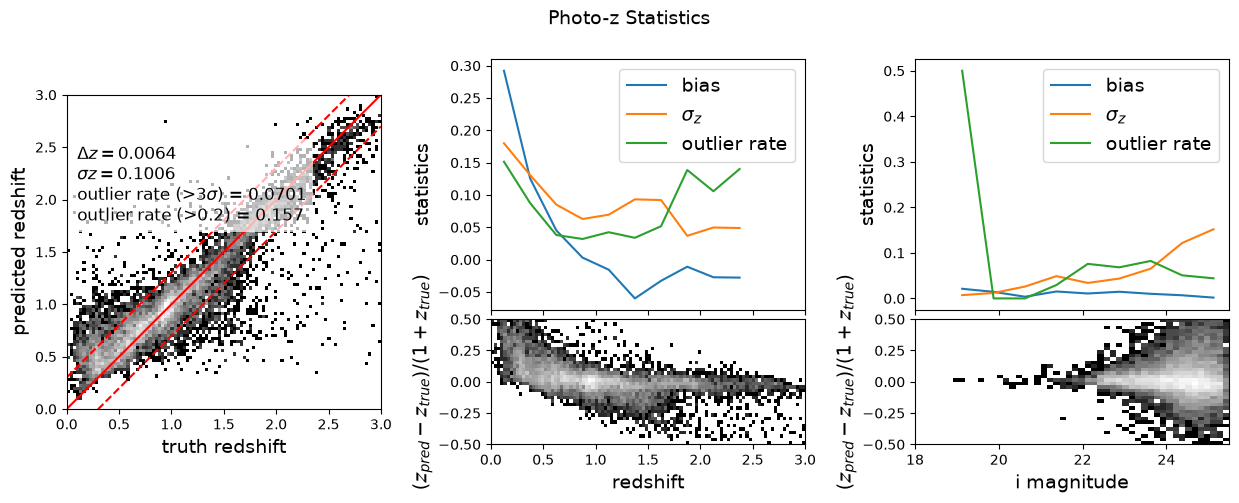

<Figure size 640x480 with 0 Axes>

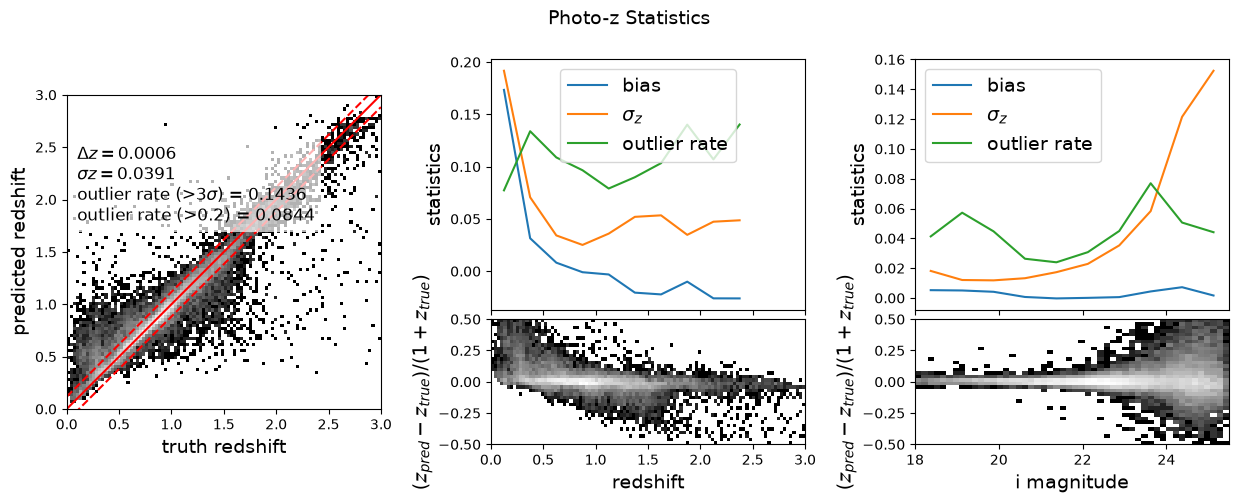

<Figure size 640x480 with 0 Axes>

outputs/znn_pretrained_popcosmos/pz_challenge_taskset_3_flagship_pz_estimate_1yr.hdf5 checks passed: [1, 2, 3, 4, 5, 6, 7]

========== task set 3: flagship_10yr ==========
spec-selected: 45.5%, COSMOS-only: 54.5%; many-band vs spec-z on 5396 overlap objects: bias 0.0004, scatter 0.0128, |dz|>0.2 rate 0.0072


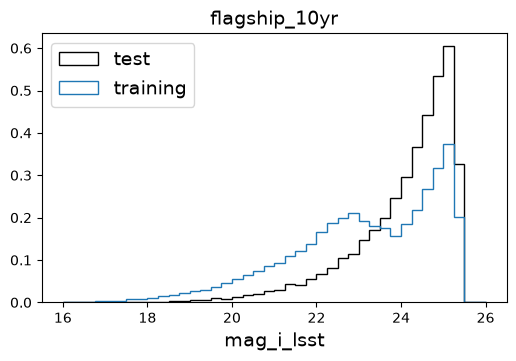


--- Fold 1/5 ---
Epoch 1/100


I0000 00:00:1791450723.604810  345489 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_558533__.37


250/250 - 5s - 22ms/step - loss: 0.0073 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0066 - val_loss: 0.0057 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 0.0064 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 0.0064 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 0.0062 - val_loss: 0.0054 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 0.0061 - val_loss: 0.0055 - learning_rate: 5.0000e-04
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 0.0061 - val_loss: 0.0054 - learning_rate: 5.0000e-04
Epoch 8/100

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 0.0061 - val_loss: 0.0054 - learning_rate: 5.0000e-04
Epoch 9/100
250/250 - 1s - 3ms/step - loss: 0.0059 - val_loss: 0.0054 - learning_rate: 2.

I0000 00:00:1791450739.843296  345492 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_577271__.37


250/250 - 5s - 20ms/step - loss: 0.0070 - val_loss: 0.0061 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0065 - val_loss: 0.0059 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 0.0063 - val_loss: 0.0059 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 0.0062 - val_loss: 0.0061 - learning_rate: 0.0010
Epoch 5/100

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 0.0062 - val_loss: 0.0061 - learning_rate: 0.0010
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 0.0060 - val_loss: 0.0057 - learning_rate: 5.0000e-04
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 0.0060 - val_loss: 0.0058 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 0.0059 - val_loss: 0.0058 - learning_rate: 5.0000e-04
Epoch 9/100

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 0.0059 - val_loss: 0.0058 - learning_rate: 5.0000

...

250/250 - 5s - 21ms/step - loss: 0.0068 - val_loss: 0.0064 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0063 - val_loss: 0.0064 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 0.0062 - val_loss: 0.0063 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 0.0061 - val_loss: 0.0063 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 0.0060 - val_loss: 0.0062 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 0.0059 - val_loss: 0.0062 - learning_rate: 5.0000e-04
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 0.0059 - val_loss: 0.0062 - learning_rate: 5.0000e-04
Epoch 8/100

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 0.0059 - val_loss: 0.0062 - learning_rate: 5.0000e-04
Epoch 9/100
250/250 - 1s - 3ms/step - loss: 0.0058 - val_loss: 0.0062 - learning_rate: 2.

I0000 00:00:1791450769.939346  345492 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_611733__.37


250/250 - 5s - 20ms/step - loss: 0.0070 - val_loss: 0.0061 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0064 - val_loss: 0.0059 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 0.0063 - val_loss: 0.0060 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 0.0061 - val_loss: 0.0060 - learning_rate: 0.0010
Epoch 5/100

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 0.0062 - val_loss: 0.0061 - learning_rate: 0.0010
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 0.0060 - val_loss: 0.0058 - learning_rate: 5.0000e-04
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 0.0059 - val_loss: 0.0057 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 0.0059 - val_loss: 0.0057 - learning_rate: 5.0000e-04
Epoch 9/100
250/250 - 1s - 3ms/step - loss: 0.0058 - val_loss: 0.0057 - learning_rate: 5.0000e-04
Epoch 10/100

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.00

I0000 00:00:1791450791.910098  345490 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_639161__.37


250/250 - 5s - 19ms/step - loss: 0.0073 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0066 - val_loss: 0.0052 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 0.0065 - val_loss: 0.0053 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 0.0064 - val_loss: 0.0052 - learning_rate: 0.0010
Epoch 5/100

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 0.0064 - val_loss: 0.0053 - learning_rate: 0.0010
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 0.0062 - val_loss: 0.0052 - learning_rate: 5.0000e-04
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 0.0061 - val_loss: 0.0051 - learning_rate: 5.0000e-04
Epoch 8/100

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 0.0061 - val_loss: 0.0052 - learning_rate: 5.0000e-04
Epoch 9/100
250/250 - 1s - 3ms/step - loss: 0.0060 - val_loss: 0.0051 - learning_rate: 2.5000

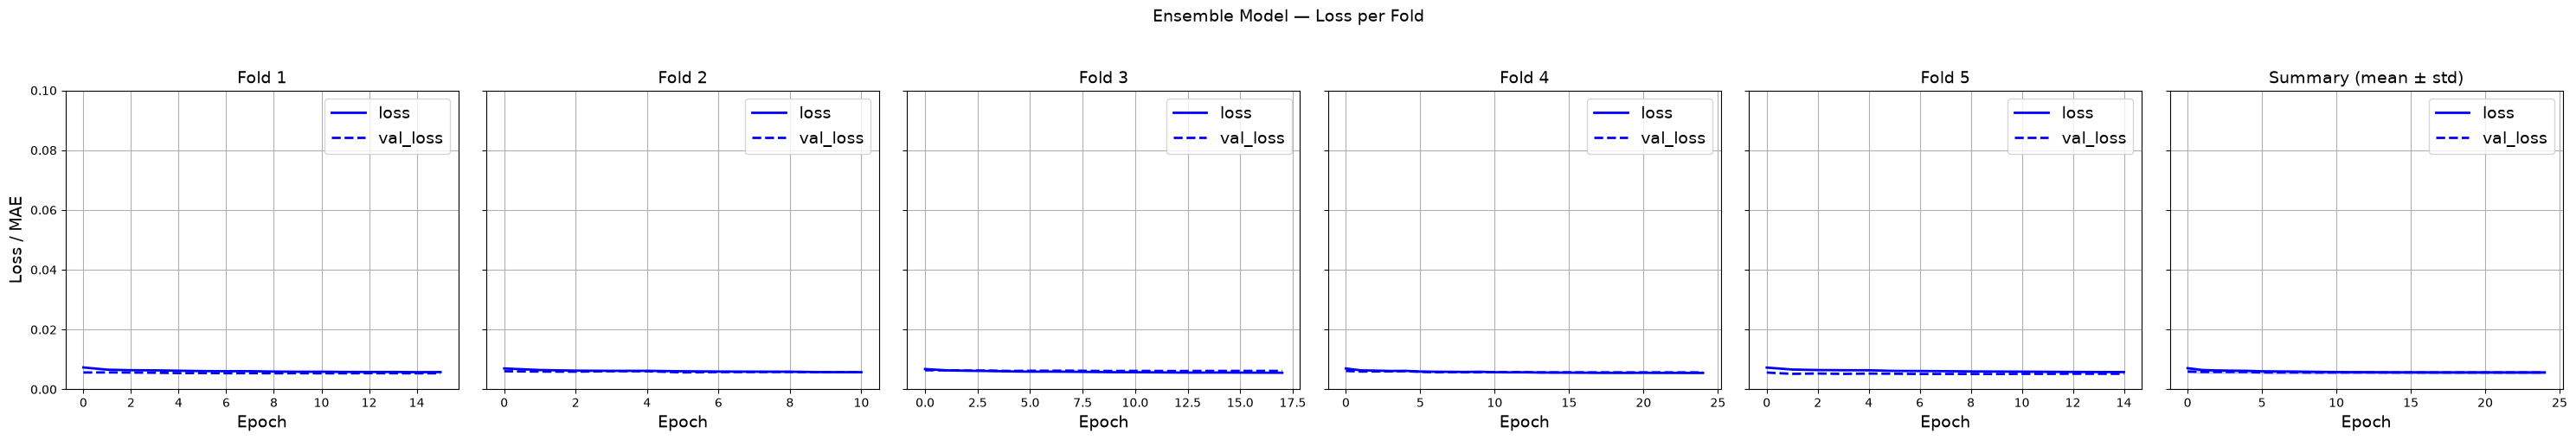

/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/u2/j/jaimerz/UCL/mlpz_cnn_deepset

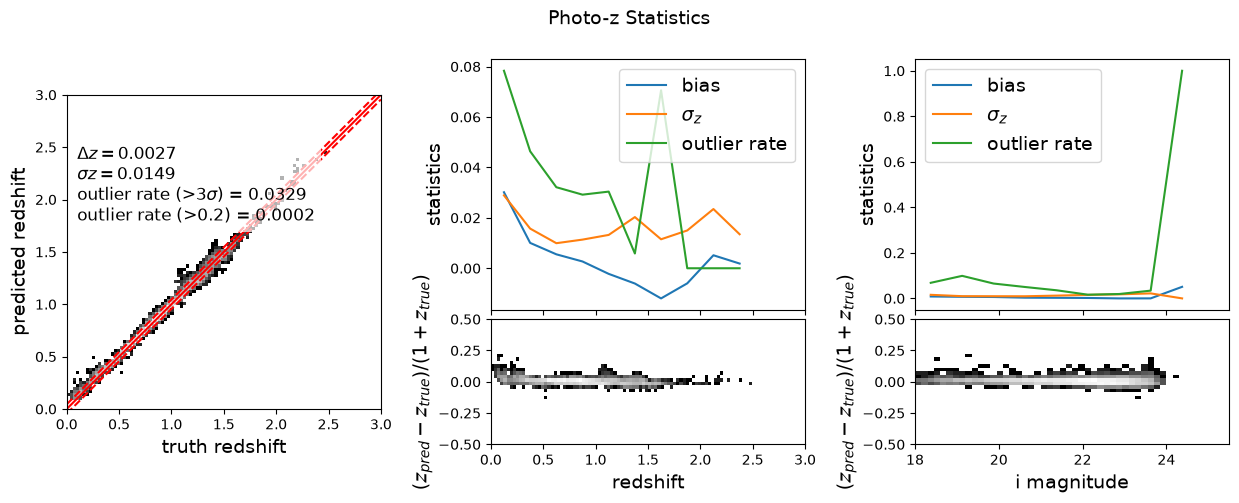

<Figure size 640x480 with 0 Axes>

/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/qp/metrics/array_metrics.py:27: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  return stats.anderson_ksamp([p_random_variables, q_random_variables], **kwargs)
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/qp/metrics/array_metrics.py:27: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  return stats.anderson_ksamp([p_random_variables, q_random_variables], **kwargs)


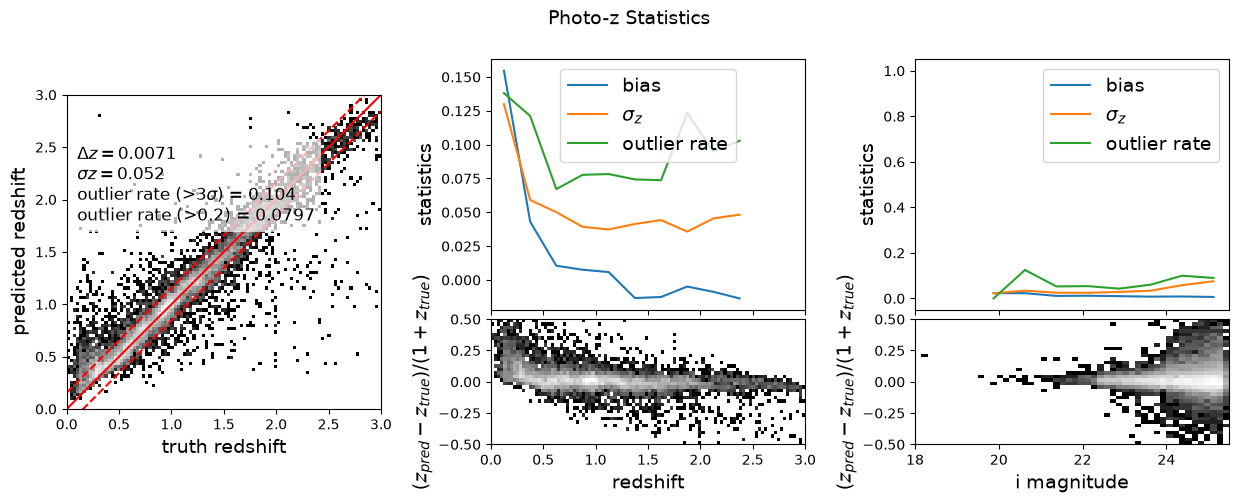

<Figure size 640x480 with 0 Axes>

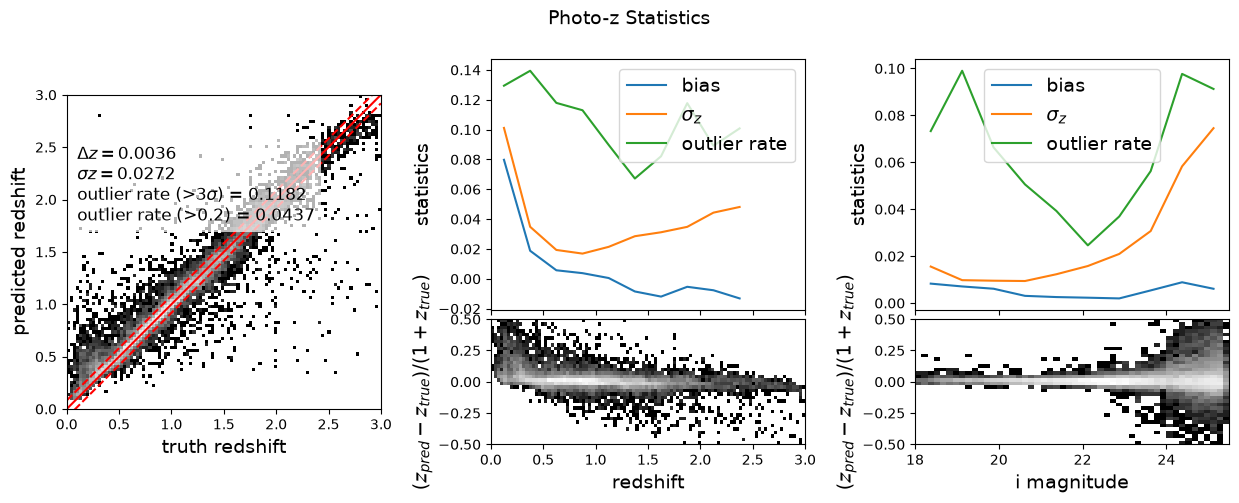

<Figure size 640x480 with 0 Axes>

outputs/znn_pretrained_popcosmos/pz_challenge_taskset_3_flagship_pz_estimate_10yr.hdf5 checks passed: [1, 2, 3, 4, 5, 6, 7]


In [5]:
results = {}

for SIM in SIMS:
    for SCENARIO in SCENARIOS:
        config = f"{SIM}_{SCENARIO}"
        print(f"\n========== task set {TASKSET}: {config} ==========")

        train_file = os.path.join(DATA_DIR, f"pz_challenge_taskset_{TASKSET}_{SIM}_training_{SCENARIO}.hdf5")
        test_file = os.path.join(DATA_DIR, f"pz_challenge_taskset_{TASKSET}_{SIM}_test_{SCENARIO}.hdf5")
        train = znn.read_catalog(train_file)
        test = znn.read_catalog(test_file)
        z_ref, subsets = reference_redshifts(train)

        # how representative is the training set of the test set?
        bins = np.linspace(16, 26, 41)
        plt.figure(figsize=[6, 3.5])
        plt.hist(test["mag_i_lsst"], bins, density=True, histtype="step", color="k", label="test")
        plt.hist(train["mag_i_lsst"], bins, density=True, histtype="step", label="training")
        plt.xlabel("mag_i_lsst")
        plt.title(config)
        plt.legend()
        plt.show()

        X, _ = znn.catalog_to_XY(train, BANDS, REF_BAND, FEATURE_CONFIG)
        rng = np.random.default_rng(NOISE_SEED)

        idx_fit, idx_val = train_test_split(np.arange(len(train)), test_size=VAL_FRAC, random_state=SEED)
        trained_models, histories = znn.train_ensembles(
            znn.build_model, X[idx_fit], z_ref[idx_fit], N_SPLITS=N_SPLITS, EPOCHS=EPOCHS, random_state=SEED, pretraining=PRETRAINING
        )
        znn.plot_ensemble_losses(histories, ylim=(0, 0.1))

        val = train.iloc[idx_val]
        for name, mask in subsets.items():
            m = mask[idx_val]
            results[(config, name)] = evaluate(
                trained_models, val[m], z_ref[idx_val][m], rng, title=f"{config}: {name}"
            )

        # submission files: subtask 1 p(z) and subtask 2 model
        estimate_file = os.path.join(OUT_DIR, f"pz_challenge_taskset_{TASKSET}_{SIM}_pz_estimate_{SCENARIO}.hdf5")
        model_file = os.path.join(OUT_DIR, f"pz_challenge_taskset_{TASKSET}_{SIM}_pz_model_{SCENARIO}.pkl")

        pz_test = predict(trained_models, test, rng)
        pz_test.write_to(estimate_file)
        znn.save_ensemble_file(model_file, trained_models, BANDS, REF_BAND, FEATURE_CONFIG)

        checks = submit_utils.check_pz_submission_file(estimate_file, test_file)
        print(estimate_file, "checks passed:", checks)
        assert checks == [1, 2, 3, 4, 5, 6, 7], "submission file failed the challenge format checks"

## Summary

Metric values and points against the challenge scoring tiers (`pz_data_challenge.scoring.metric_dict`: three nested ranges per metric, one point per range), per configuration and held-out subset.

In [6]:
table = pd.DataFrame(results).T
table.index.names = ["configuration", "subset"]

points = pd.DataFrame({key: tier_points(values) for key, values in results.items()}).T
points["total"] = points.sum(axis=1)
points.index.names = ["configuration", "subset"]
n_max = sum(len(r) for r in scoring.metric_dict.values())

print("metric values")
print(table.round(4).to_string())
print(f"\npoints (out of 3 per metric, {n_max} in total)")
print(points.to_string())

metric values
                                                             mean     std  abs_outlier_rate      ks       CvM      ksamp    outlier  pit_outlier_direct
configuration subset                                                                                                                                   
cardinal_1yr  held-out spec-selected (vs spec-z)           0.0049  0.0181            0.0176  0.1560  148.5632   517.5779     0.0035              0.0090
              held-out COSMOS-only (vs many-band photo-z)  0.0114  0.0897            0.1182  0.1503   61.1082   284.1785    30.9819              0.0649
              held-out all                                 0.0050  0.0276            0.0522  0.1516  198.0401   756.8641     0.0588              0.0283
cardinal_10yr held-out spec-selected (vs spec-z)           0.0029  0.0130            0.0013  0.1133   77.1193   281.4005     0.0245              0.0203
              held-out COSMOS-only (vs many-band photo-z)  0.0074  0.0478 